In [1]:
from micrograd.models.value import Value
from micrograd.utils.vis import draw_dot

In [ ]:
import random
from typing import List

class Neuron:
    def __init__(self, nin: int) -> None:
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x: List[Value | float | int]) -> Value:
        # act = w*x + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), start=self.b)
        out = act.tanh()    
        return out

    def parameters(self) -> List[Value]:
        return self.w + [self.b]

class Layer:
    def __init__(self, nin: int, nout: int) -> None:
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x: List[Value | float | int]) -> Value | List[Value]:
        x = [x] if not isinstance(x, List) else x 
        outs = [neuron(x) for neuron in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self) -> List[Value]:
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin: int, nouts: List[int]) -> None:
        nins = [nin] + nouts
        self.layers = [Layer(nins[i], nouts[i]) for i in range(len(nouts))]

    def __call__(self, x: List[Value | float | int]) -> Value | List[Value]:
        for layer in self.layers:
            x = layer(x)
        return x        

    def parameters(self) -> List[Value]:
        return [p for layer in self.layers for p in layer.parameters()]


In [3]:
x = [2.0, 3.0]
neuron = Neuron(len(x))
neuron(x)

Value(data=-0.8428094947632344

In [4]:
x = [2.0, 3.0, 4.0]
layer = Layer(3, 5)
layer(x)

[Value(data=-0.9999793021067286,
 Value(data=0.9347370785289414,
 Value(data=-0.9979864224096773,
 Value(data=0.9900966940856429,
 Value(data=0.9968081454953125]

Value(data=0.4002804803292584


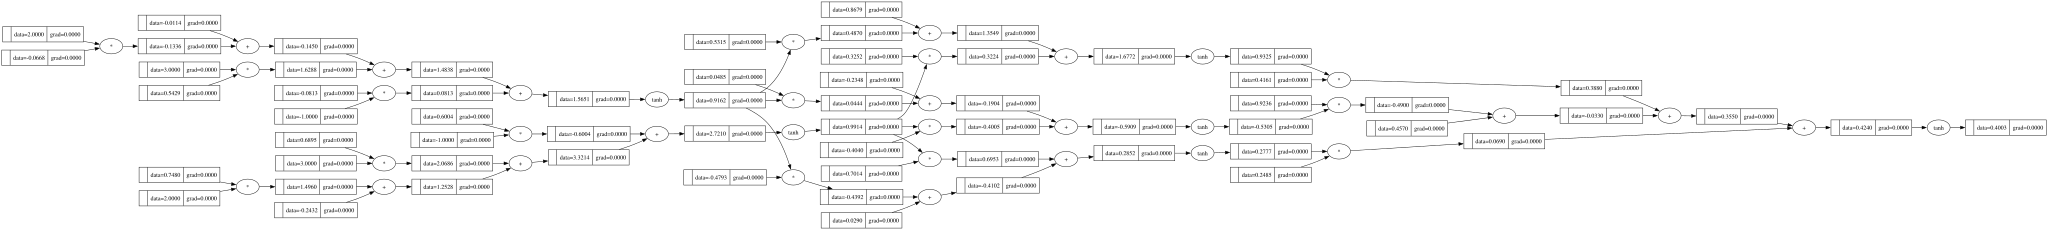

In [26]:
x = [2.0, 3.0, -1.0]
mlp = MLP(3, [2, 3, 1])

o = mlp(x)
print(o)
draw_dot(o)

In [103]:
mlp = MLP(3, [2, 3, 1])

# Create a tiny dataset
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
y_gt = [1.0, -1.0, -1.0, 1.0]

# Initial predictions
y_pred = [mlp(x) for x in xs]
y_pred

[Value(data=-0.6648677673761877,
 Value(data=-0.6821089884161292,
 Value(data=-0.7019229836455081,
 Value(data=-0.6534700813254206]

In [104]:
# Calculate the mean square error (MSE)
def mse(y_pred, y_gt):
    return sum((yi - yi_gt)**2 for yi, yi_gt in zip(y_pred, y_gt))

loss = mse(y_pred, y_gt)
loss.backward()
print(loss)
# draw_dot(loss) # a huge graph

Value(data=5.695652595611077


In [105]:
params = mlp.parameters()
print('number of parameters:', len(params))
params

number of parameters: 21


[Value(data=0.9643849324789346,
 Value(data=-0.3135149909224917,
 Value(data=0.8222116953660028,
 Value(data=-0.9544190552848921,
 Value(data=-0.38083413348274875,
 Value(data=0.2063021280522359,
 Value(data=-0.14637211066782352,
 Value(data=-0.8624468663710771,
 Value(data=0.43369363063907196,
 Value(data=-0.32005498937955057,
 Value(data=-0.5591001934314495,
 Value(data=-0.885310045583926,
 Value(data=0.4470570309443349,
 Value(data=-0.46376009236820415,
 Value(data=-0.2995719007692861,
 Value(data=0.005801430346354275,
 Value(data=0.04560211256360902,
 Value(data=-0.2078076645902125,
 Value(data=0.3761649471780102,
 Value(data=-0.8337869260623478,
 Value(data=-0.6494592146680456]

In [106]:
print('data:', mlp.layers[0].neurons[0].w[0].data)
print('grad:', mlp.layers[0].neurons[0].w[0].grad)

data: 0.9643849324789346
grad: 0.4158056759774025


In [ ]:
# Now, we can apply gradient descent algorithm to lower the loss
# Since gradient vector shows the steepest ascent, and we want to minimize the loss,
# we should go the reverse direction of the gradient

# Update all the parameters by a tiny amount (step size) according to their negative gradient
lr = 0.01 # step size or learning rate (LR)
for p in mlp.parameters():
    p.data += lr * -p.grad

# Since the gradient is positive, decreasing the param value will decrease the loss
# So, the updated param should have a lower value because it has a positive impact on the loss 
print('updated data', mlp.layers[0].neurons[0].w[0].data) 

updated data 0.9602268757191607


In [108]:
# Now, hopefully, the loss value should be lower than it's prev value (Value(data=4.598333584985271)
y_pred = [mlp(x) for x in xs]
loss = mse(y_pred, y_gt)
print(loss)

Value(data=5.325032375968256


In [ ]:
# And this is the gradient descent: forward pass, backward pass and update
n_steps = 20
lr = 0.05 # sligtly larger learning rate to converge faster 
for i in range(n_steps):
    # Forward pass
    y_pred = [mlp(x) for x in xs]
    loss = mse(y_pred, y_gt)

    # Backward pass
    loss.backward()

    # Update
    for p in mlp.parameters():
        p.data += lr * -p.grad

    print(f"step: {i + 1}, loss: {loss.data}")

print('---')
print('y_gt vs. y_pred')
for yi, yi_gt in zip(y_pred, y_gt):
    print(yi_gt, '|' , yi.data)

step: 1, loss: 5.325032375968256
step: 2, loss: 4.460854601720664
step: 3, loss: 3.085592406014123
step: 4, loss: 1.99794041262628
step: 5, loss: 1.9256418621732008
step: 6, loss: 2.1148935875164194
step: 7, loss: 1.913284764113321
step: 8, loss: 1.1157369717728711
step: 9, loss: 0.28489738015282534
step: 10, loss: 0.0459494196119724
step: 11, loss: 0.00913033672328466
step: 12, loss: 0.002891166471644924
step: 13, loss: 0.002172495778305736
step: 14, loss: 0.008550435514530986
step: 15, loss: 0.09998741184441431
step: 16, loss: 0.090045998462906
step: 17, loss: 0.0027335656151311694
step: 18, loss: 9.665975754516004e-05
step: 19, loss: 1.2299886376845179e-05
step: 20, loss: 4.141936552725491e-06
---
y_gt vs. y_pred
1.0 | 0.9989233263768325
-1.0 | -0.998957176847297
-1.0 | -0.9988232545373478
1.0 | 0.9992855068578252


In [110]:
# Wait, we made a very big mistake! All the gradients are accumulated on top of the previos iteration gradients
# We need to zero them before the next backward call!
# 

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
y_gt = [1.0, -1.0, -1.0, 1.0]

mlp = MLP(3, [2, 3, 1])

# And this is the gradient descent: forward pass, backward pass and update
n_steps = 20
lr = 0.05 # sligtly larger learning rate to converge faster 
for i in range(n_steps):
    # Forward pass
    y_pred = [mlp(x) for x in xs]
    loss = mse(y_pred, y_gt)

    # Backward pass
    # Zero out the gradients (equivalent to .zero_grad() in pytorch)
    for p in mlp.parameters():
        p.grad = 0.0
    loss.backward()

    # Update
    for p in mlp.parameters():
        p.data += lr * -p.grad

    print(f"step: {i + 1}, loss: {loss.data}")

print('---')
print('y_gt vs. y_pred')
for yi, yi_gt in zip(y_pred, y_gt):
    print(yi_gt, '|' , yi.data)

step: 1, loss: 4.936706342859229
step: 2, loss: 4.304022705091169
step: 3, loss: 4.07948208264019
step: 4, loss: 3.9341329742220963
step: 5, loss: 3.845675102810742
step: 6, loss: 3.7645701400285914
step: 7, loss: 3.6833584302890987
step: 8, loss: 3.597472717350697
step: 9, loss: 3.5040344744347465
step: 10, loss: 3.401747900482093
step: 11, loss: 3.29109937971179
step: 12, loss: 3.1741124422321674
step: 13, loss: 3.052876023100411
step: 14, loss: 2.9269565666045474
step: 15, loss: 2.7912973860615913
step: 16, loss: 2.6361570625622437
step: 17, loss: 2.449117087515851
step: 18, loss: 2.2194998461364426
step: 19, loss: 1.946872036964529
step: 20, loss: 1.6502626894576309
---
y_gt vs. y_pred
1.0 | 0.45380892481389085
-1.0 | -0.06715023772073717
-1.0 | -0.6092057719718066
1.0 | 0.4264067720064643
